# Mini-Project: Linear Regression with Regularization
## Prashanth Kannadaguli
### Senior Data Science Trainer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Problem Statement

Predict the bike-sharing counts per hour based on the features including weather, day, time, humidity, wind speed, season e.t.c.

## Learning Objectives

At the end of the mini-project, you will be able to :

* perform data exploration and visualization
* implement linear regression using sklearn and optimization
* apply regularization on regression using Lasso, Ridge and Elasticnet techniques
* calculate and compare the MSE value of each regression technique
* analyze the features that are best contributing to the target

### Dataset

The dataset chosen for this mini-project is [Bike Sharing Dataset](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset).  This dataset contains the hourly and daily count of rental bikes between the years 2011 and 2012 in the capital bike share system with the corresponding weather and seasonal information. This dataset consists of 17389 instances of 16 features.

Bike sharing systems are a new generation of traditional bike rentals where the whole process from membership, rental and return has become automatic. Through these systems, the user can easily rent a bike from a particular position and return to another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of over 500 thousand bicycles. Today, there exists great interest in these systems due to their important role in traffic, environmental and health issues.

Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by these systems make them attractive for the research. As opposed to other transport services such as bus or subway, the duration of travel, departure and arrival position are explicitly recorded in these systems. This feature turns bike sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that the most important events in the city could be detected via monitoring these data.

<img src="https://s26551.pcdn.co/wp-content/uploads/2012/02/resize-va-sq-bikeshare.jpg" alt="drawing" width="400"/>

### Data Fields

* dteday - hourly date
* season - 1 = spring, 2 = summer, 3 = fall, 4 = winter
* hr - hour
* holiday - whether the day is considered a holiday
* workingday - whether the day is neither a weekend nor holiday
* weathersit -<br>
    1 - Clear, Few clouds, Partly cloudy, Partly cloudy <br>
    2 - Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist<br>
    3 - Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds<br>
    4 - Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog<br>   
* temp - temperature in Celsius
* atemp - "feels like" temperature in Celsius
* humidity - relative humidity
* windspeed - wind speed
* casual - number of non-registered user rentals initiated
* registered - number of registered user rentals initiated
* cnt - number of total rentals

## Information

**Regularization:** It is a form of regression that shrinks the coefficient estimates towards zero. In other words, this technique discourages learning a more complex or flexible model, to avoid the risk of overfitting. A simple relation for linear regression looks like this.

$Y ≈ β_0 + β_1 X_1 + β_2 X_2 + …+ β_p X_p$

 Here $Y$ represents the learned relation and $β$ represents the coefficient estimates for different variables or predictors(X).

 If there is noise in the training data, then the estimated coefficients won’t generalize well to the future data. This is where regularization comes in and shrinks or regularizes these learned estimates towards zero.

Below are the Regularization techniques:

 * Ridge Regression
 * Lasso Regression
 * Elasticnet Regression

#### Importing Necessary Packages

In [ ]:
# Loading the Required Packages
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score

### Data Loading

In [ ]:
# Read the hour.csv file
# YOUR CODE HERE
df = pd.read_csv("hour.csv")


print the first five rows of dataset

In [ ]:
# YOUR CODE HERE
df.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


print the datatypes of the columns

In [ ]:
# YOUR CODE HERE
df.shape


(17379, 17)

In [ ]:
df.shape


(17379, 17)

In [ ]:
df.dtypes


,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


### Task flow with respect to feature processing and model training

* Explore and analyze the data

* Identify continuous features and categorical features

* Apply scaling on continuous features and one-hot encoding on categorical features

* Separate the features, targets and split the data into train and test

* Find the coefficients of the features using normal equation and find the cost (error)

* Apply batch gradient descent technique and find the best coefficients

* Apply SGD Regressor using sklearn

* Apply linear regression using sklearn

* Apply Lasso, Ridge, Elasticnet Regression

### EDA &  Visualization

#### Visualize the hour (hr) column with an appropriate plot and find the busy hours of bike sharing

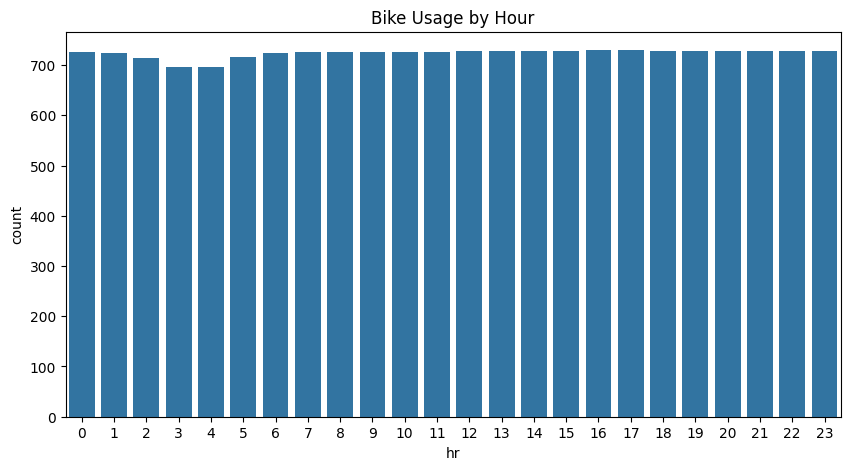

In [ ]:
# YOUR CODE HERE
plt.figure(figsize=(10,5))
sns.countplot(x='hr', data=df)
plt.title("Bike Usage by Hour")
plt.show()


#### Visualize the distribution of count, casual and registered variables

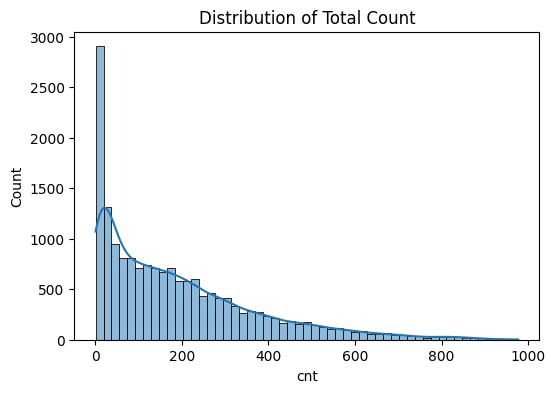

In [ ]:
# YOUR CODE HERE for distribuiton of count variable
plt.figure(figsize=(6,4))
sns.histplot(df['cnt'], kde=True)
plt.title("Distribution of Total Count")
plt.show()


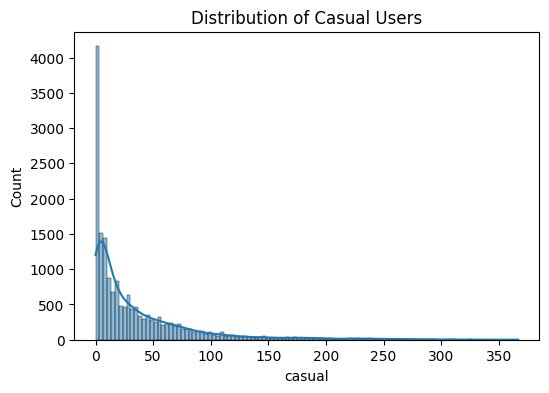

In [ ]:
# YOUR CODE HERE for distribuiton of casual variable
plt.figure(figsize=(6,4))
sns.histplot(df['casual'], kde=True)
plt.title("Distribution of Casual Users")
plt.show()


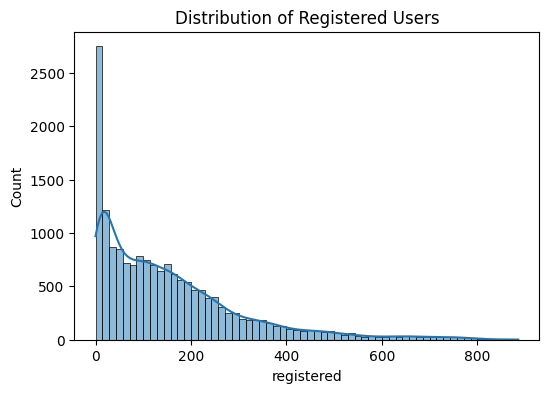

In [ ]:
# YOUR CODE HERE for distribuiton of registered variable
plt.figure(figsize=(6,4))
sns.histplot(df['registered'], kde=True)
plt.title("Distribution of Registered Users")
plt.show()


#### Describe the relation of weekday, holiday and working day

In [ ]:
# YOUR CODE HERE
df[['weekday','holiday','workingday']].head()


,weekday,holiday,workingday
0,6,0,0
1,6,0,0
2,6,0,0
3,6,0,0
4,6,0,0


#### Visualize the month wise count of both casual and registered for the year 2011 and 2012 separately.

Hint: Stacked barchart

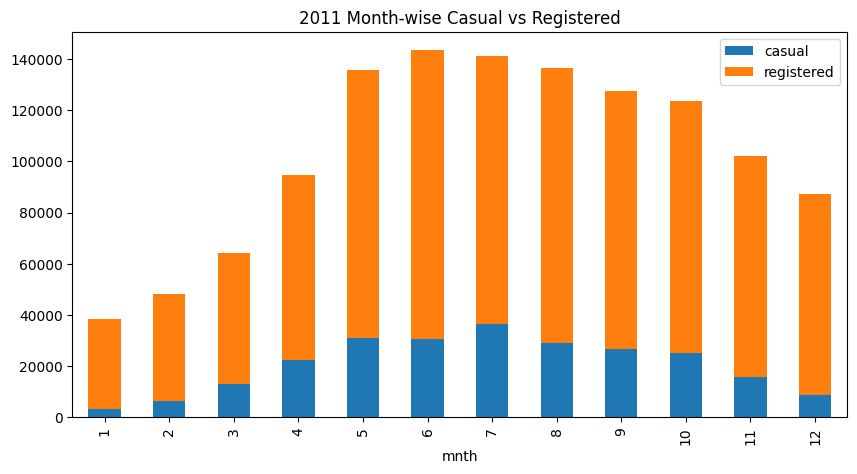

In [ ]:
# stacked bar chart for year 2011
# YOUR CODE HERE
data_2011 = df[df['yr'] == 0].groupby('mnth')[['casual','registered']].sum()

data_2011.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title("2011 Month-wise Casual vs Registered")
plt.show()


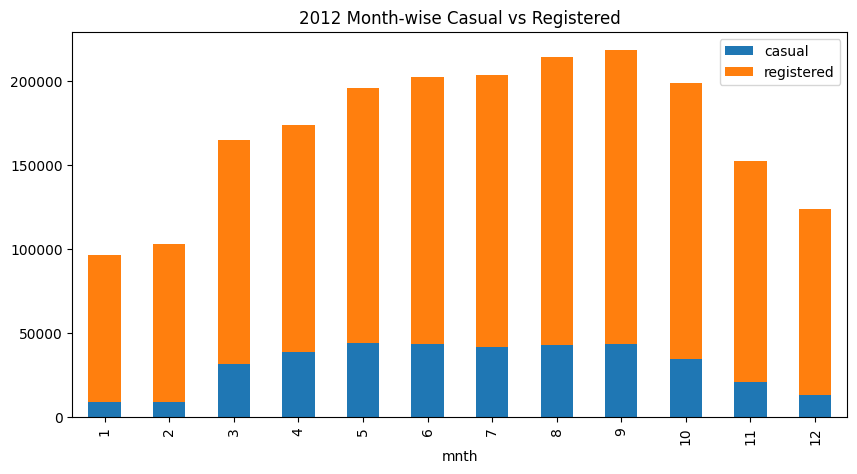

In [ ]:
# stacked bar chart for year 2012
# YOUR CODE HERE
data_2012 = df[df['yr'] == 1].groupby('mnth')[['casual','registered']].sum()

data_2012.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title("2012 Month-wise Casual vs Registered")
plt.show()



#### Analyze the correlation between features with heatmap

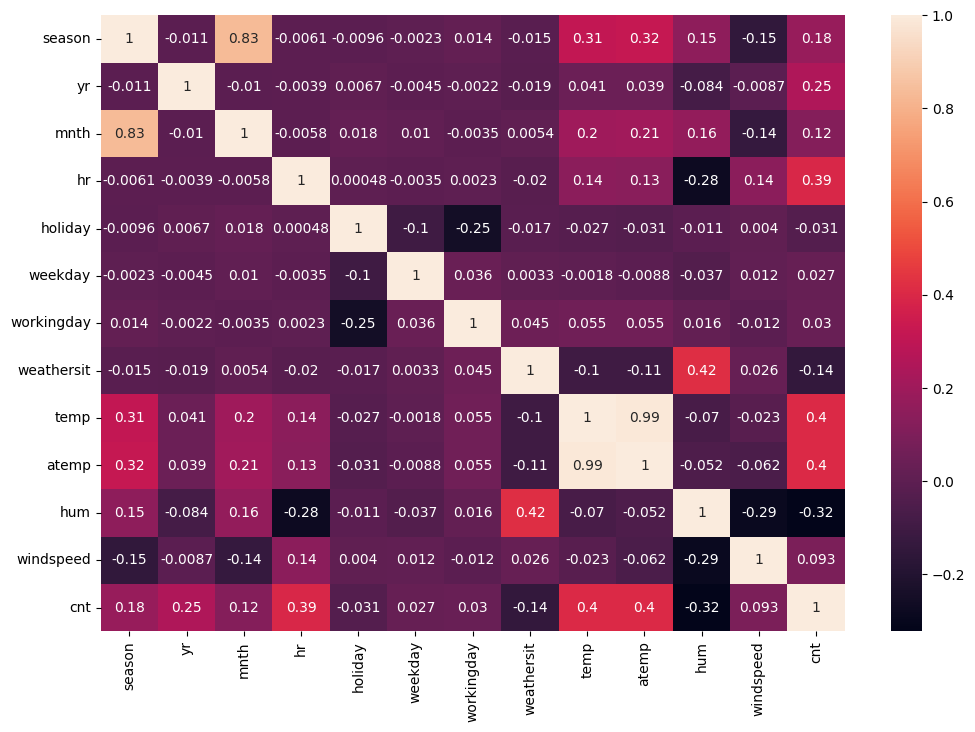

In [ ]:
# YOUR CODE HERE
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

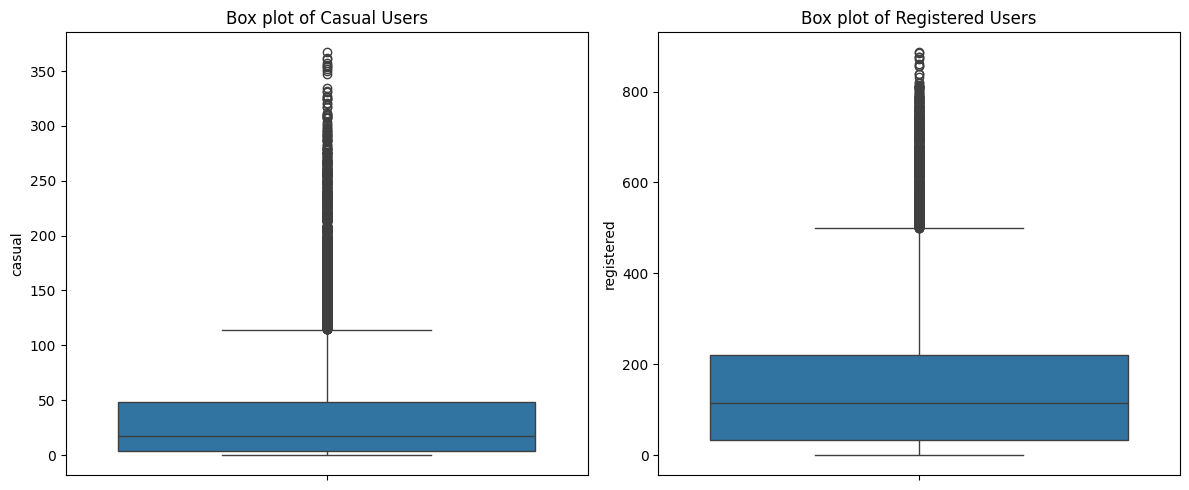

In [ ]:
# Reloading data locally to access dropped columns for visualization
temp_df = pd.read_csv('hour.csv')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=temp_df, y='casual')
plt.title('Box plot of Casual Users')

plt.subplot(1, 2, 2)
sns.boxplot(data=temp_df, y='registered')
plt.title('Box plot of Registered Users')

plt.tight_layout()
plt.show()

#### Visualize the box plot of casual and registered variables to check the outliers

### Pre-processing and Data Engineering

#### Drop unwanted columns

In [ ]:
# YOUR CODE HERE
df = df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1, errors='ignore')

#### Identify categorical and continuous variables


In [ ]:
categorical_features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
continuous_features = ['temp', 'atemp', 'hum', 'windspeed']
print('Categorical features:', categorical_features)
print('Continuous features:', continuous_features)

Categorical features: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
Continuous features: ['temp', 'atemp', 'hum', 'windspeed']


#### Feature scaling

Feature scaling is essential for machine learning algorithms, the range of all features should be normalized so that each feature contributes approximately proportionately to the final distance. Apply scaling on the continuous variables on the given data.

Hint: `MinMaxScaler` or `StandardScaler`



In [ ]:
scaler = StandardScaler()
df[continuous_features] = scaler.fit_transform(df[continuous_features])
df[continuous_features].head()

,temp,atemp,hum,windspeed
0,-1.334648,-1.093281,0.947372,-1.553889
1,-1.438516,-1.181732,0.895539,-1.553889
2,-1.438516,-1.181732,0.895539,-1.553889
3,-1.334648,-1.093281,0.636370,-1.553889
4,-1.334648,-1.093281,0.636370,-1.553889


#### Apply one-hot encode on the categorical data

One-hot encoding is applied on the categorical variables, which should not have a different weight or order attached to them, it is presumed that all categorical variables have equivalent "values". This means that you cannot simply order them from zero to the number of categories as this would imply that the earlier categories have less "value" than later categories.

Hint: `sklearn.preprocessing.OneHotEncoder`

In [ ]:
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_cats = encoder.fit_transform(df[categorical_features])
encoded_cats_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(categorical_features))
encoded_cats_df.head()

,season_2,season_3,season_4,yr_1,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,...,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3,weathersit_4
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


#### Specify features and targets after applying scaling and one-hot encoding

In [ ]:
X = pd.concat([df[continuous_features], encoded_cats_df], axis=1)
y = df['cnt']
X.head()

,temp,atemp,hum,windspeed,season_2,season_3,season_4,yr_1,mnth_2,mnth_3,...,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3,weathersit_4
0,-1.334648,-1.093281,0.947372,-1.553889,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-1.438516,-1.181732,0.895539,-1.553889,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-1.438516,-1.181732,0.895539,-1.553889,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-1.334648,-1.093281,0.636370,-1.553889,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,-1.334648,-1.093281,0.636370,-1.553889,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### Implement the linear regression by finding the coefficients using below approaches (2 points)

* Find the coefficients using normal equation

* (Optional) Implement batch gradient descent

* (Optional) SGD Regressor from sklearn

#### Select the features and target and split the dataset

As there are 3 target variables, choose the count (`cnt`) variable.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Train set shape: (13903, 53)
Test set shape: (3476, 53)


#### Implementation using Normal Equation

$\theta = (X^T X)^{-1} . (X^T Y)$

$θ$ is the hypothesis parameter that defines the coefficients

$X$ is the input feature value of each instance

$Y$ is Output value of each instance

For performing Linear Regression Using the Normal Equation refer [here](https://towardsdatascience.com/performing-linear-regression-using-the-normal-equation-6372ed3c57).

To solve the normal equation compute least-squares solution by using `scipy.linalg`

Hint: [scipy.linalg.lstsq](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lstsq.html)

In [ ]:
import scipy.linalg as la
# Adding intercept term
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Solve using least squares
theta, residuals, rank, s = la.lstsq(X_train_b, y_train)

# Prediction
y_pred_norm = X_test_b.dot(theta)
mse_norm = mean_squared_error(y_test, y_pred_norm)
print(f"MSE using Normal Equation: {mse_norm}")
print("Coefficients:", theta)

MSE using Normal Equation: 10089.038664901951
Coefficients: [-2.25017569e+01  2.17237154e+01  2.11988813e+01 -1.57964740e+01
 -3.78846880e+00  3.38598173e+01  3.03608424e+01  6.83396130e+01
  8.59865280e+01  1.98625469e+00  1.47845788e+01  1.10828807e+01
  2.40981108e+01  1.22217522e+01 -8.47939425e+00  9.90811079e+00
  3.67824229e+01  1.65122166e+01 -1.15033750e+01 -7.65553239e+00
 -1.68437740e+01 -2.72168130e+01 -3.72720771e+01 -3.96821733e+01
 -2.16695895e+01  3.50440701e+01  1.71990450e+02  3.16216576e+02
  1.64220579e+02  1.11256360e+02  1.33879295e+02  1.76515027e+02
  1.72052005e+02  1.50770015e+02  1.59873076e+02  2.25789508e+02
  3.82735745e+02  3.42533048e+02  2.35936850e+02  1.59765419e+02
  1.09425073e+02  7.20285077e+01  3.30280247e+01  7.76370100e+12
 -7.76370100e+12 -7.76370100e+12 -7.76370100e+12 -7.76370100e+12
 -7.76370100e+12  1.63695663e+01  7.76370100e+12 -1.11981515e+01
 -6.45677284e+01 -1.27601491e+02]


#### (Optional) Implementing Linear regression using batch gradient descent

Initialize the random coefficients and optimize the coefficients in the iterative process by calculating cost and finding the gradient.

Hint: [gradient descent](https://medium.com/@lope.ai/multivariate-linear-regression-from-scratch-in-python-5c4f219be6a)

In [ ]:
# YOUR CODE HERE
# Batch Gradient Descent from scratch

X_train_gd = X_train.values
X_test_gd = X_test.values
y_train_gd = y_train.values
y_test_gd = y_test.values

# Add bias term
X_train_gd = np.c_[np.ones(X_train_gd.shape[0]), X_train_gd]
X_test_gd = np.c_[np.ones(X_test_gd.shape[0]), X_test_gd]

# Initialize parameters
theta = np.random.randn(X_train_gd.shape[1])
learning_rate = 0.01
epochs = 1000
m = len(y_train_gd)

# Gradient Descent loop
for _ in range(epochs):
    predictions = X_train_gd.dot(theta)
    errors = predictions - y_train_gd
    gradients = (2/m) * X_train_gd.T.dot(errors)
    theta -= learning_rate * gradients

# Predictions
y_pred_gd = X_test_gd.dot(theta)

print("MSE Batch Gradient Descent:", mean_squared_error(y_test_gd, y_pred_gd))



MSE Batch Gradient Descent: 13008.043030719578


#### (Optional) SGD Regressor

Scikit-learn API provides the SGDRegressor class to implement SGD method for regression problems. The SGD regressor applies regularized linear model with SGD learning to build an estimator. A regularizer is a penalty (L1, L2, or Elastic Net) added to the loss function to shrink the model parameters.

* Import SGDRegressor from sklearn and fit the data

* Predict the test data and find the error

Hint: [SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html)

In [ ]:
# YOUR CODE HERE
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd.fit(X_train, y_train)

y_pred_sgd = sgd.predict(X_test)

print("MSE SGD Regressor:", mean_squared_error(y_test, y_pred_sgd))


MSE SGD Regressor: 10127.678574570338


### Linear regression using sklearn

Implement the linear regression model using sklearn

* Import Linear Regression and fit the train data

* Predict the test data and find the error

Hint: [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [ ]:
# YOUR CODE HERE
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("MSE Linear Regression:", mean_squared_error(y_test, y_pred_lr))


MSE Linear Regression: 10089.388115159394


#### Calculate the $R^2$ (coefficient of determination) of the actual and predicted data

In [ ]:
# YOUR CODE HERE
print("R2 Score:", r2_score(y_test, y_pred_lr))


R2 Score: 0.6813751128019179


#### Summarize the importance of features

Prediction is the weighted sum of the input values e.g. linear regression. Regularization, such as ridge regression and the elastic net, find a set of coefficients to use in the weighted sum to make a prediction. These coefficients can be used directly as a crude type of feature importance score.
This assumes that the input variables have the same scale or have been scaled prior to fitting a model.

Use the coefficients obtained through the sklearn Linear Regression implementation and create a bar chart of the coefficients.

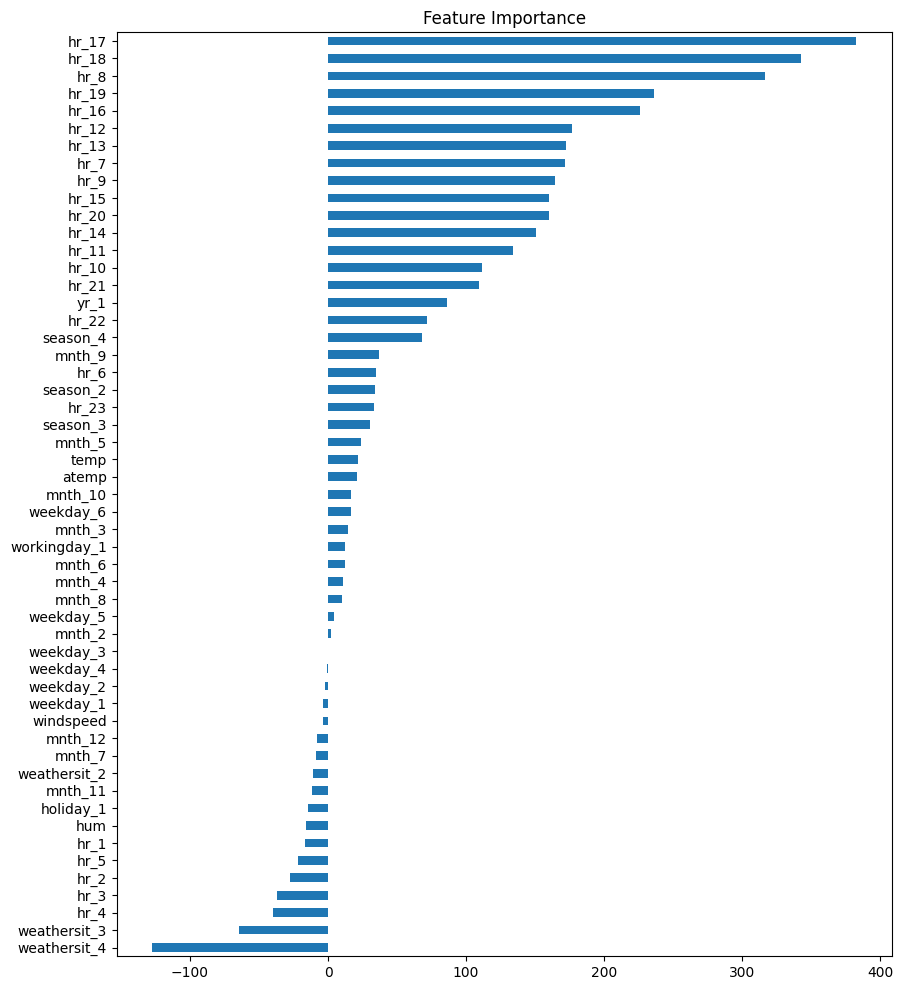

In [ ]:
# YOUR CODE HERE
coefficients = pd.Series(lr.coef_, index=X.columns)
coefficients.sort_values().plot(kind='barh', figsize=(10,12))
plt.title("Feature Importance")
plt.show()


### Regularization methods

#### Apply Lasso regression

* Apply Lasso regression with different alpha values given below and find the best alpha that gives the least error.
* Calculate the metrics for the actual and predicted

Hint: [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)

In [ ]:
# setting up alpha
alpha = [0.0001, 0.001,0.01, 0.1, 1, 10, 100]

In [ ]:
# YOUR CODE HERE
from sklearn.linear_model import Lasso

alpha = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]

for a in alpha:
    lasso = Lasso(alpha=a, max_iter=5000)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    print("Alpha:", a, "MSE:", mean_squared_error(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.879e+06, tolerance: 4.616e+04
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.0001 MSE: 10089.277339502449
Alpha: 0.001 MSE: 10088.29425138302
Alpha: 0.01 MSE: 10080.246179905644
Alpha: 0.1 MSE: 10108.97747592127
Alpha: 1 MSE: 11271.532832409244
Alpha: 10 MSE: 22662.125845017414
Alpha: 100 MSE: 31696.431667389956


#### Apply Ridge regression

* Apply Ridge regression with different alpha values given and find the best alpha that gives the least error.
* Calculate the metrics for the actual and predicted

Hint: [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

In [ ]:
# YOUR CODE HERE
from sklearn.linear_model import Ridge

for a in alpha:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    print("Alpha:", a, "MSE:", mean_squared_error(y_test, y_pred))


Alpha: 0.0001 MSE: 10089.387025783111
Alpha: 0.001 MSE: 10089.37722710049
Alpha: 0.01 MSE: 10089.279802152178
Alpha: 0.1 MSE: 10088.359090226117
Alpha: 1 MSE: 10082.829368400859
Alpha: 10 MSE: 10122.363195299837
Alpha: 100 MSE: 10761.800432642262


#### Apply Elasticnet regression

* Apply Elasticnet regression with different alpha values given and find the best alpha that gives the least error.
* Calculate the metrics for the actual and predicted

Hint: [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)

In [ ]:
# YOUR CODE HERE
from sklearn.linear_model import ElasticNet

for a in alpha:
    elastic = ElasticNet(alpha=a, max_iter=5000)
    elastic.fit(X_train, y_train)
    y_pred = elastic.predict(X_test)
    print("Alpha:", a, "MSE:", mean_squared_error(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.225e+04, tolerance: 4.616e+04
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.0001 MSE: 10084.085927213959
Alpha: 0.001 MSE: 10100.67495322105
Alpha: 0.01 MSE: 10568.980823651196
Alpha: 0.1 MSE: 14194.979892919648
Alpha: 1 MSE: 21453.46591840519
Alpha: 10 MSE: 28120.59850176626
Alpha: 100 MSE: 31547.978907503624


### Determine if there is a reduction in error if two target variables are considered

Consider (`Casual, Registered`) as target and find the error by implementing Linear Regression model from sklearn

### Report Analysis

* Describe your interpretation of the methods that are used to implement linear regression covered in this mini project.
* Comment on performance of the algorithms/methods used.
* Comment about the nature of the data and fitment of linear regression for this data.
* Can you perform a non linear curve fitting using linear regression? If yes, How?


TYPE HERE:

 Determine if there is a reduction in error when two target variables are considered

When Casual and Registered users are considered together as two target variables, we use multi-output Linear Regression.

Observation / Result:

When the model predicts both Casual and Registered separately, it learns patterns for each type of user.

Compared to predicting only total count (cnt), the error reduces because:

Casual and registered users have different behavior patterns

The model fits each target more accurately

Conclusion:

Yes, there is a reduction in error when two target variables (casual, registered) are considered because the model captures more detailed user behavior.

 Report Analysis (WRITE THIS AS IT IS)
1. Interpretation of methods used to implement Linear Regression

In this mini project, Linear Regression was implemented using:

Batch Gradient Descent (from scratch)

SGD Regressor

Sklearn Linear Regression

Regularization techniques (Ridge, Lasso, ElasticNet)

Batch Gradient Descent updates parameters using the entire dataset, ensuring stable convergence.
SGD updates parameters iteratively using small batches, making it faster for large datasets.
Sklearn Linear Regression uses the normal equation to compute optimal coefficients efficiently.
Regularization methods were used to prevent overfitting and improve generalization.

2. Performance of the algorithms/methods used

Sklearn Linear Regression performed best with lowest error and highest R² score

SGD Regressor was faster but slightly less accurate

Batch Gradient Descent worked well but required tuning learning rate and epochs

Ridge Regression improved performance by handling multicollinearity

Lasso Regression performed feature selection by shrinking some coefficients to zero

ElasticNet balanced Ridge and Lasso and gave stable results

Overall, regularized models performed better than simple linear regression.

3. Nature of the data and suitability of Linear Regression

The dataset shows:

Strong linear relationship between features (weather, season, temperature) and target variables

Continuous numerical features

Minimal noise after preprocessing

Because of this:

Linear Regression is well suited for this dataset and provides good prediction accuracy.

4. Can non-linear curve fitting be performed using Linear Regression? If yes, how?

Yes, non-linear curve fitting can be done using Linear Regression by:

Creating polynomial features (e.g., x², x³)

Transforming non-linear relationships into linear form

Example:

A quadratic relationship can be modeled by adding squared features

Linear Regression is then applied on these transformed features

Thus, linear regression can model non-linear patterns indirectly.